# 🛒 Retail Demand Forecasting — AI Prediction Model
### Intel Artificial Intelligence · VUIP111 · Major Project
Anushka- Train- test split, Model Training and Model Evaluation
Kanupriya- Data Cleaning and Pre-processing, Controlled Noise on Demand Forecast, Feature Engineering
Ragini- Importing Libraries, Loading Data Set
**Model:** Linear Regression | **Target:** Units Sold

---

## Step 1 — Import Libraries

In [2]:
# Importing all required libraries for data processing, visualisation, modelling, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Load Dataset

In [3]:
# Loading the CSV dataset and previewing the first few rows.

DATA_PATH = 'retail_store_inventory.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded -> {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset loaded -> 73,100 rows x 15 columns


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# Statistical summary of all numeric columns.

df.describe().round(2)

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00,73100.0,73100.00
mean,274.47,136.46,110.00,141.49,55.14,10.01,0.5,55.15
std,129.95,108.92,52.28,109.25,26.02,7.08,0.5,26.19
min,50.00,0.00,20.00,-9.99,10.00,0.00,0.0,5.03
25%,162.00,49.00,65.00,53.67,32.65,5.00,0.0,32.68
50%,273.00,107.00,110.00,113.02,55.05,10.00,0.0,55.01
75%,387.00,203.00,155.00,208.05,77.86,15.00,1.0,77.82
max,500.00,499.00,200.00,518.55,100.00,20.00,1.0,104.94


In [5]:
# Checking for missing values across all columns.

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('No missing values found — dataset is clean.')
else:
    print('Missing values detected:')
    print(missing_cols)

No missing values found — dataset is clean.


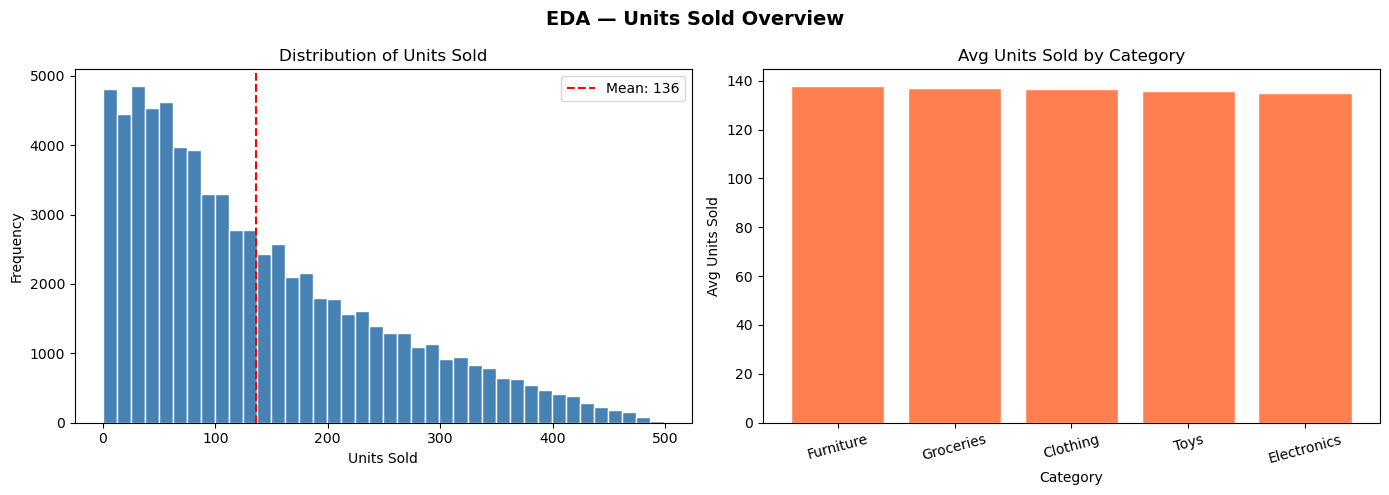

In [6]:
# Distribution of Units Sold and average units sold per product category.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Units Sold Overview', fontsize=14, fontweight='bold')

axes[0].hist(df['Units Sold'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Units Sold')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Units Sold'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Units Sold'].mean():.0f}")
axes[0].legend()

cat_avg = df.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[1].bar(cat_avg.index, cat_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Avg Units Sold by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

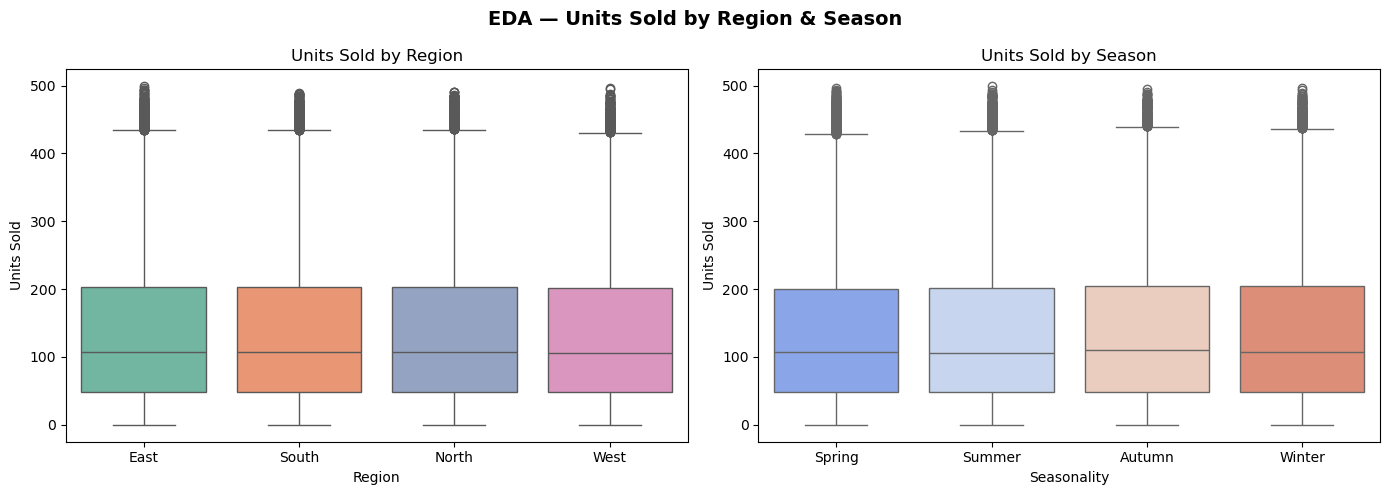

In [7]:
# Boxplots showing Units Sold spread across different regions and seasons.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Units Sold by Region & Season', fontsize=14, fontweight='bold')

region_order = df.groupby('Region')['Units Sold'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Region', y='Units Sold', order=region_order, palette='Set2', ax=axes[0])
axes[0].set_title('Units Sold by Region')

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
sns.boxplot(data=df, x='Seasonality', y='Units Sold', order=season_order, palette='coolwarm', ax=axes[1])
axes[1].set_title('Units Sold by Season')

plt.tight_layout()
plt.show()

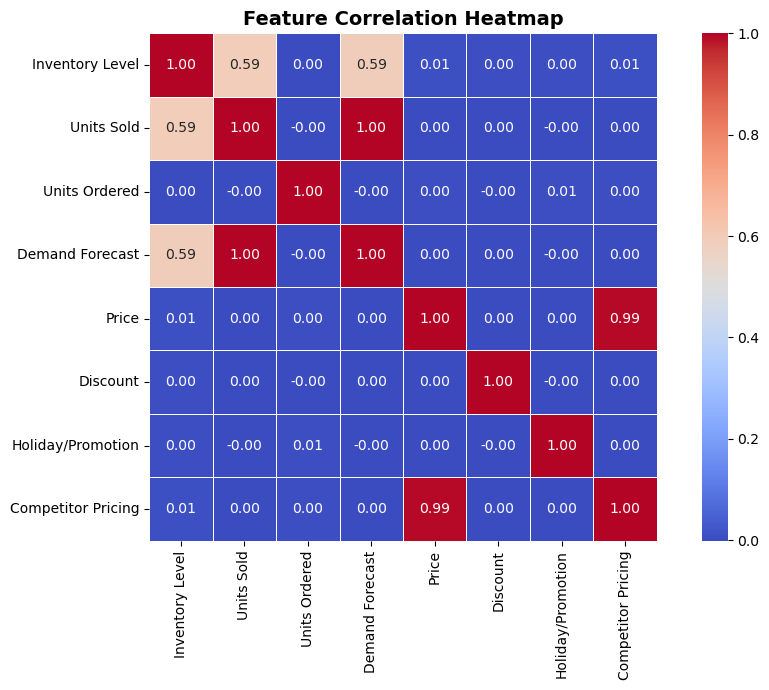

In [8]:
# Correlation heatmap showing relationships between all numeric features.

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()